In [1]:
import numpy as np
import matplotlib.pyplot as plt
from geometry_class import Geometry
from parametrizations_adapted_reswater import Parameter
from visualization_fct import get_grid, eval_fct_on_grid, plot_scalar_function
from dolfinx.fem import functionspace, Function, Expression
import pickle
from dolfinx import mesh
import ufl
from basix.ufl import element
from scipy.interpolate import griddata

In [2]:
filename = "Test16_Annika_freezing"
with open("./solutions/"+filename+".pkl", "rb") as f:
    data_Annika = pickle.load(f)

nx = data_Annika["geometry"]["nx"]
nz = data_Annika["geometry"]["nz"]
interval = data_Annika["saving_interval"]
geom = Geometry()
geom.make_from_dict(data_Annika["geometry"])
domain = geom.make_domain(nx, nz, celltype=mesh.CellType.quadrilateral)
[P0, P1, P2, P3] = geom.corner_points
V = functionspace(domain, ("CG", 1))
Q = functionspace(domain, ("DG", 0))
Vq = functionspace(domain, element("DG", domain.basix_cell(), 0, shape=(2,)))
z = ufl.SpatialCoordinate(domain)[1]
hw = Function(V)
phi = Function(Q)
T_i = Function(V)
T_w = Function(V)
q = Function(Vq)
layer_params = {
    1: {"d_i": 0.3e-3, "rho_s": 390,
        "locator": lambda x: x[1] >= geom.slope*x[0]+P3[1]/2},
    2: {"d_i": 0.4e-3, "rho_s": 309,
        "locator": lambda x: x[1] < geom.slope*x[0]+P3[1]/2},
}

layered = data_Annika["parameter"]["is_layered"]
if layered:
    p = Parameter(domain, layer_params) # heterogen
else:
    p = Parameter(domain) # homogen
grid, x_plot, z_plot = get_grid(P0, P1, P2, P3, nx, nz)
m = 1 - 1/p.N
points = np.column_stack((x_plot.ravel(), z_plot.ravel()))
x1 = np.linspace(x_plot.min(), x_plot.max(), 250)
z1 = np.linspace(z_plot.min(), z_plot.max(), 250)
X, Z = np.meshgrid(x1, z1)
x_lines = np.linspace(x_plot.min(), x_plot.max(), 25)
start_pts = np.array([x_lines, geom.slope*x_lines+P3[1]-0.01])

In [3]:
def Se(h_c, alpha, N):
    return (1 + (- alpha * h_c)**N)**((1 - N) / N)
if layered:
    alpha_eval = eval_fct_on_grid(grid, p.alpha, domain).reshape((nz, nx))
    N_eval = eval_fct_on_grid(grid, p.N, domain).reshape((nz, nx))
theta_all = []
porosity_all = []
Tw_all = []
Ti_all = []
Qx_all = []
Qz_all = []
q_max = 0.0
theta_max = 0.0
for t in range(len(data_Annika["times"])):
    hw.x.array[:] = data_Annika["h_w"][t]
    phi.x.array[:] = data_Annika["phi"][t]
    T_i.x.array[:] = data_Annika["T_i"][t]
    T_w.x.array[:] = data_Annika["T_w"][t]
    pressure_head = eval_fct_on_grid(grid, hw, domain).reshape((nz, nx))
    h_c = pressure_head * (pressure_head < 0)
    porosity = eval_fct_on_grid(grid, phi, domain).reshape((nz, nx))
    porosity_all.append(porosity)
    Ti_all.append(eval_fct_on_grid(grid, T_i, domain).reshape((nz, nx)))
    Tw_all.append(eval_fct_on_grid(grid, T_w, domain).reshape((nz, nx)))
    # calculate LWC
    if layered:
        theta_all.append(p.theta_r.value + (0.9*porosity - p.theta_r.value)*Se(h_c, alpha_eval, N_eval))
    else:
        theta_all.append(p.theta_r.value + (0.9*porosity - p.theta_r.value)*Se(h_c, p.alpha.value, p.N.value))
    theta_max = max(theta_max, np.nanmax(theta_all[t]))
    # calculate specific discharge
    hc = ufl.min_value(hw, 0.0)
    S_e = (1 + (-p.alpha*hc)**p.N)**((1-p.N)/p.N)
    kr = S_e**0.5 * (1 - (1-S_e**(1/m))**m)**2
    Ks = (
        3*(p.d_i/2)**2
        * ufl.exp(-0.013*p.rho_i*(1-phi))
        * p.rho_w*p.g/p.mu_w
    )
    h_tot = hw + z
    q_expr = -Ks * kr * ufl.grad(h_tot)
    expr = Expression(q_expr, Vq.element.interpolation_points)
    q.interpolate(expr)
    q_eval = eval_fct_on_grid(grid, q, domain)
    q_x = q_eval[:,0].reshape((nz, nx))
    q_z = q_eval[:,1].reshape((nz, nx))
    Qx = griddata(points, q_x.ravel(), (X, Z), method="linear")
    Qz = griddata(points, q_z.ravel(), (X, Z), method="linear")
    Qx_all.append(Qx)
    Qz_all.append(Qz)
    q_max = max(q_max, np.nanmax(np.sqrt(Qx**2 + Qz**2)))


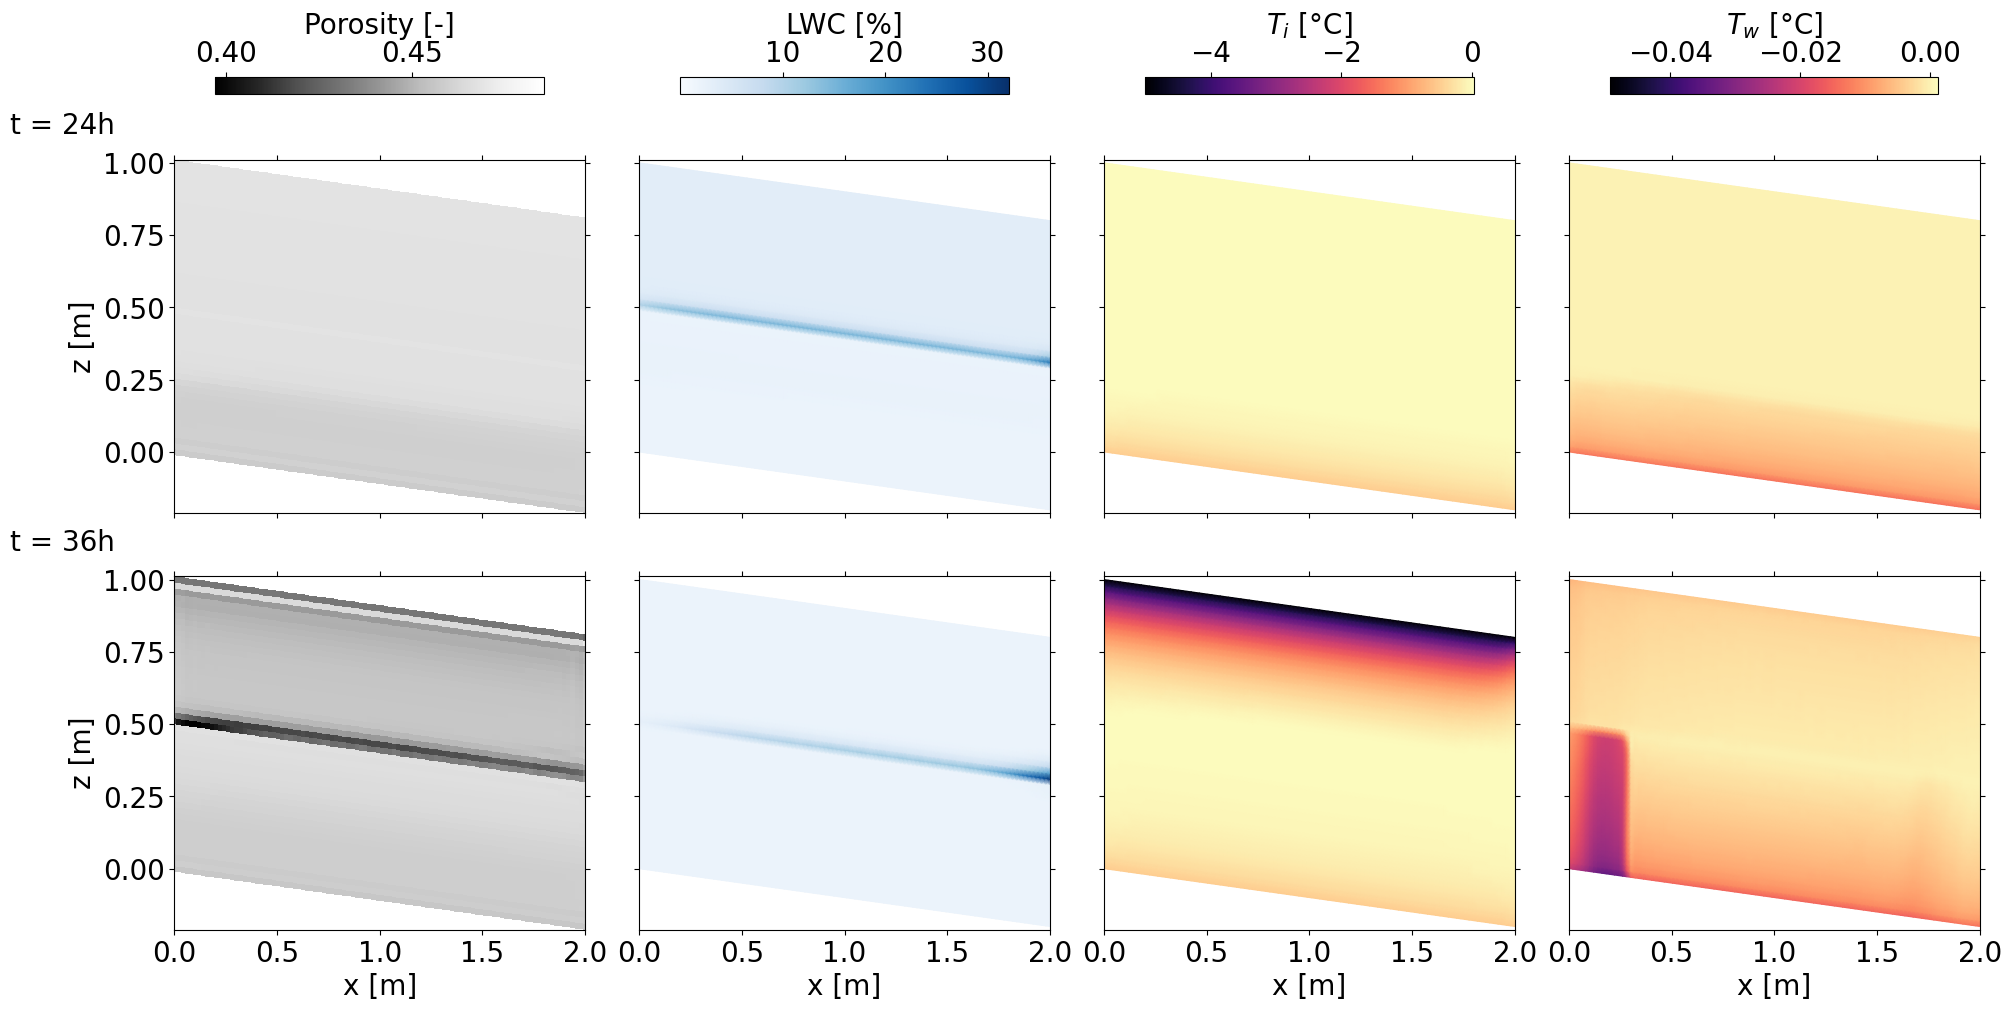

In [4]:
t_obs = [0, -1]
norm = plt.Normalize(vmin=0, vmax=q_max)
plt.rcParams.update({'font.size': 20})
fig, ax = plt.subplots(
    len(t_obs), 4, figsize=(20, len(t_obs)*5), layout="constrained", sharex=True, sharey=True)
plt.setp(ax, xlim=(0, geom.length))

for i, t in enumerate(t_obs):
    p1 = ax[i, 0].pcolormesh(
        x_plot, z_plot, porosity_all[t], cmap="Greys_r",
        vmin=np.min(porosity_all), vmax=np.max(porosity_all))
    p2 = ax[i, 1].pcolormesh(
        x_plot, z_plot, theta_all[t]*100, cmap="Blues", shading="gouraud",
        vmin=np.min(theta_all), vmax=np.max(theta_all)*100)
    p3 = ax[i, 2].pcolormesh(
        x_plot, z_plot, Ti_all[t], cmap="magma", shading="gouraud",
        vmin=np.min(Ti_all), vmax=np.max(Ti_all))
    p4 = ax[i, 3].pcolormesh(
        x_plot, z_plot, Tw_all[t], cmap="magma", shading="gouraud",
        vmin=np.min(Tw_all), vmax=np.max(Tw_all))
    # strm = ax[i, 1].streamplot(
    #     X, Z, Qx_all[t], Qz_all[t], density=2,
    #     color=np.sqrt(Qx_all[t]**2 + Qz_all[t]**2), norm=norm,start_points=start_pts.T)
    ax[i, 0].set_ylabel("z [m]")
    ax[i, 0].tick_params(tick2On=True)
    ax[i, 1].tick_params(tick2On=True)
    ax[i, 2].tick_params(tick2On=True)
    ax[i, 3].tick_params(tick2On=True)
    if i == len(t_obs)-1:
        ax[i, 0].set_xlabel("x [m]")
        ax[i, 1].set_xlabel("x [m]")
        ax[i, 2].set_xlabel("x [m]")
        ax[i, 3].set_xlabel("x [m]")
    ax[i, 0].text(-0.8, 1.1, f"t = {data_Annika['times'][t]/3600+24:.0f}h")
c1 = fig.colorbar(p1, ax=ax[0,0], shrink=0.8, location="top")
c1.set_label("Porosity [-]")
c2 = fig.colorbar(p2, ax=ax[0,1], shrink=0.8, location="top")
c2.set_label("LWC [%]")
c3 = fig.colorbar(p3, ax=ax[0,2], shrink=0.8, location="top")
c3.set_label(r"$T_i$ [°C]")
c4 = fig.colorbar(p4, ax=ax[0,3], shrink=0.8, location="top")
c4.set_label(r"$T_w$ [°C]")

#### Funktioniert nicht so gut

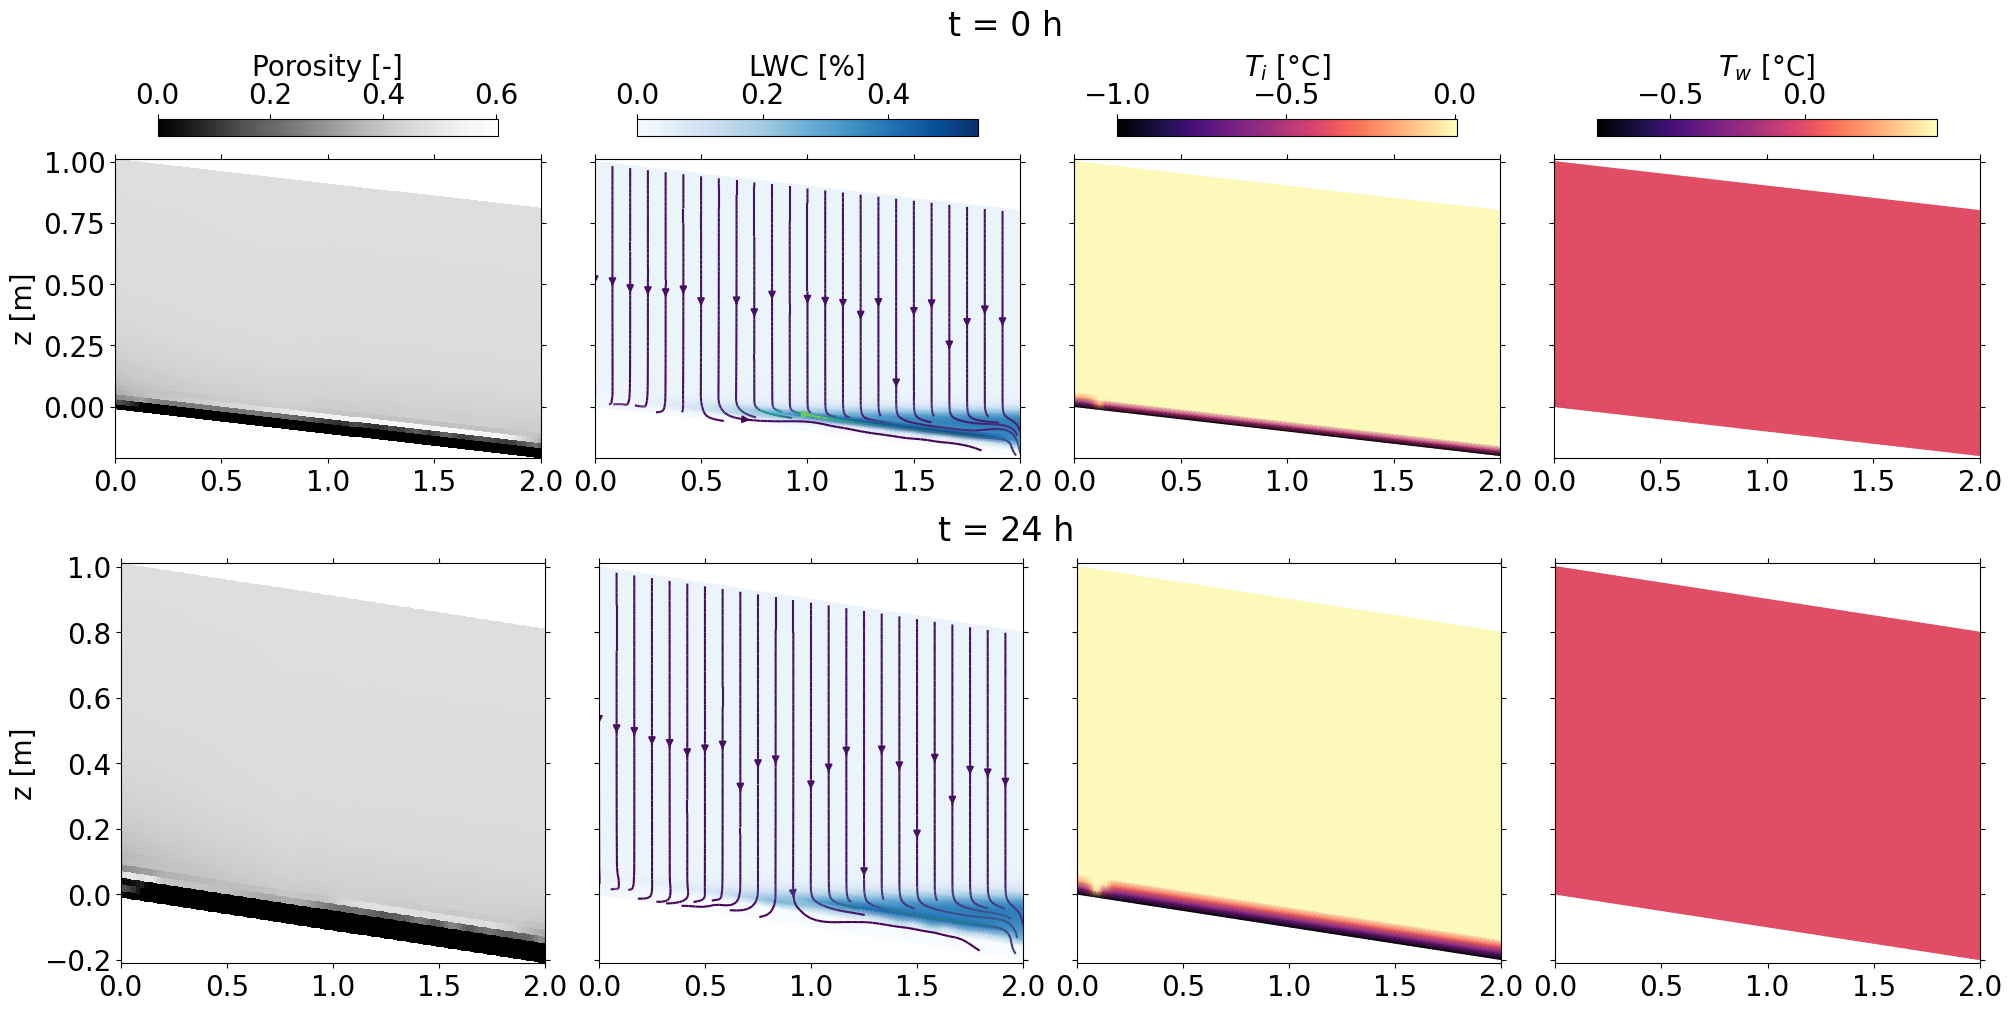

In [64]:
t_obs = [0, 48]
norm = plt.Normalize(vmin=0, vmax=q_max)
plt.rcParams.update({'font.size': 20})

fig = plt.figure(figsize=(20, len(t_obs)*5), constrained_layout=True)
subfigs = fig.subfigures(nrows=len(t_obs), ncols=1)
for i, (t, subfig) in enumerate(zip(t_obs, subfigs)):
    subfig.suptitle(f"t = {data_Annika['times'][t]/3600:.0f} h",fontsize=24)
    ax = subfig.subplots(nrows=1, ncols=4, sharey="row", sharex="row")
    plt.setp(ax, xlim=(0, geom.length))
    p1 = ax[0].pcolormesh(
        x_plot, z_plot, porosity_all[t],
        cmap="Greys_r", vmin=np.min(porosity_all), vmax=np.max(porosity_all))
    p2 = ax[1].pcolormesh(
        x_plot, z_plot, theta_all[t], cmap="Blues", shading="gouraud",
        vmin=np.min(theta_all), vmax=np.max(theta_all))
    strm = ax[1].streamplot(
        X, Z, Qx_all[t], Qz_all[t], density=2,
        color=np.sqrt(Qx_all[t]**2 + Qz_all[t]**2), norm=norm, start_points=start_pts.T)
    p3 = ax[2].pcolormesh(
        x_plot, z_plot, Ti_all[t], cmap="magma", shading="gouraud",
        vmin=np.min(Ti_all), vmax=np.max(Ti_all))
    p4 = ax[3].pcolormesh(
        x_plot, z_plot, Tw_all[t], cmap="magma", shading="gouraud",
        vmin=np.min(Tw_all), vmax=np.max(Tw_all))

    ax[0].set_ylabel("z [m]")
    for j in range(4):
        ax[j].tick_params(tick2On=True)
    # for j in range(1, 4):
    #     ax[j].set_yticklabels([])
    # if i == len(t_obs) - 1:
    #     for j in range(4):
    #         ax[j].set_xlabel("x [m]")
    # else:
    #     for j in range(4):
    #         ax[j].set_xticklabels("")
    if i == 0:
        c1 = subfig.colorbar(p1, ax=ax[0], shrink=0.8, location="top")
        c1.set_label("Porosity [-]")
        c2 = subfig.colorbar(p2, ax=ax[1], shrink=0.8, location="top")
        c2.set_label("LWC [%]")
        c3 = subfig.colorbar(p3, ax=ax[2], shrink=0.8, location="top")
        c3.set_label(r"$T_i$ [°C]")
        c4 = subfig.colorbar(p4, ax=ax[3], shrink=0.8, location="top")
        c4.set_label(r"$T_w$ [°C]")

